In [ ]:
from sklearn.metrics import roc_auc_score

y_true = [
    0,
    1,
    1,
    0,
    1
]

y_predictions = [
    0.1,
    0.9,
    0.4,
    0.6,
    0.61
]

roc_auc_score(y_true, y_predictions)

0.8333333333333333

# Первая часть. Исследование

In [ ]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from catboost import CatBoostClassifier, Pool

In [ ]:
!pip install catboost
!pip uninstall numpy
!pip install numpy==1.23.5


Found existing installation: numpy 1.23.5
Uninstalling numpy-1.23.5:
  Would remove:
    /usr/local/bin/f2py
    /usr/local/bin/f2py3
    /usr/local/bin/f2py3.11
    /usr/local/lib/python3.11/dist-packages/numpy-1.23.5.dist-info/*
    /usr/local/lib/python3.11/dist-packages/numpy.libs/libgfortran-040039e1.so.5.0.0
    /usr/local/lib/python3.11/dist-packages/numpy.libs/libopenblas64_p-r0-742d56dc.3.20.so
    /usr/local/lib/python3.11/dist-packages/numpy.libs/libquadmath-96973f99.so.0.0.0
    /usr/local/lib/python3.11/dist-packages/numpy/*
Proceed (Y/n)? ERROR: Operation cancelled by user
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/pip/_internal/cli/base_command.py", line 179, in exc_logging_wrapper
    status = run_func(*args)
             ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/pip/_internal/commands/uninstall.py", line 106, in run
    uninstall_pathset = req.uninstall(
                        ^^^^^^^^^^^^^^
  File "/usr/lo

## Загрузка данных (2 балла)

1) Посмотрите на случайные строчки.

2) Посмотрите, есть ли в датасете незаполненные значения (nan'ы) с помощью data.isna() или data.info() и, если нужно, замените их на что-то. Будет хорошо, если вы построите табличку с количеством nan в каждой колонке.

In [ ]:
!gdown 1ERwQ5odiK1Zvi1LtjpkzCMUswYsAX8_K  # train.csv
!gdown 1fGw_-RFwvn_LEdt91Jq-7A-wzG6mmH8r  # test.csv
!gdown 199Mt4OYZNaelT83U-HGDsEYs2YcUGQ6y  # submission.csv

Downloading...
From: https://drive.google.com/uc?id=1ERwQ5odiK1Zvi1LtjpkzCMUswYsAX8_K
To: /content/train.csv
100% 664k/664k [00:00<00:00, 37.6MB/s]
Downloading...
From: https://drive.google.com/uc?id=1fGw_-RFwvn_LEdt91Jq-7A-wzG6mmH8r
To: /content/test.csv
100% 218k/218k [00:00<00:00, 8.31MB/s]
Downloading...
From: https://drive.google.com/uc?id=199Mt4OYZNaelT83U-HGDsEYs2YcUGQ6y
To: /content/submission.csv
100% 14.7k/14.7k [00:00<00:00, 37.3MB/s]


In [ ]:
data = pd.read_csv('./train.csv')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5282 entries, 0 to 5281
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ClientPeriod              5282 non-null   int64  
 1   MonthlySpending           5282 non-null   float64
 2   TotalSpent                5282 non-null   object 
 3   Sex                       5282 non-null   object 
 4   IsSeniorCitizen           5282 non-null   int64  
 5   HasPartner                5282 non-null   object 
 6   HasChild                  5282 non-null   object 
 7   HasPhoneService           5282 non-null   object 
 8   HasMultiplePhoneNumbers   5282 non-null   object 
 9   HasInternetService        5282 non-null   object 
 10  HasOnlineSecurityService  5282 non-null   object 
 11  HasOnlineBackup           5282 non-null   object 
 12  HasDeviceProtection       5282 non-null   object 
 13  HasTechSupportAccess      5282 non-null   object 
 14  HasOnlin

In [ ]:
# Для вашего удобства списки с именами разных колонок

# Числовые признаки
num_cols = [
    'ClientPeriod',
    'MonthlySpending',
    'TotalSpent'
]

# Категориальные признаки
cat_cols = [
    'Sex',
    'IsSeniorCitizen',
    'HasPartner',
    'HasChild',
    'HasPhoneService',
    'HasMultiplePhoneNumbers',
    'HasInternetService',
    'HasOnlineSecurityService',
    'HasOnlineBackup',
    'HasDeviceProtection',
    'HasTechSupportAccess',
    'HasOnlineTV',
    'HasMovieSubscription',
    'HasContractPhone',
    'IsBillingPaperless',
    'PaymentMethod'
]

feature_cols = num_cols + cat_cols
target_col = 'Churn'

In [ ]:
data.isna().sum()

,0
ClientPeriod,0
MonthlySpending,0
TotalSpent,0
Sex,0
IsSeniorCitizen,0
HasPartner,0
HasChild,0
HasPhoneService,0
HasMultiplePhoneNumbers,0
HasInternetService,0


In [ ]:
#Информация о количестве пробелов
data.isin([' ']).sum()

,0
ClientPeriod,0
MonthlySpending,0
TotalSpent,9
Sex,0
IsSeniorCitizen,0
HasPartner,0
HasChild,0
HasPhoneService,0
HasMultiplePhoneNumbers,0
HasInternetService,0


In [ ]:
# data.replace(' ', '0', inplace=True)
# data.dropna(inplace=True)
#
# Замена пробелов на нули в числовых столбцах
for col in ['ClientPeriod', 'MonthlySpending', 'TotalSpent']:
    data[col] = data[col].replace(' ', '0')

# Преобразование числовых столбцов в числовой формат
for col in ['ClientPeriod', 'MonthlySpending', 'TotalSpent']:
    data[col] = pd.to_numeric(data[col])

# Замена пустых значений в категориальных столбцах
data['Sex'].fillna('Unknown', inplace=True)


<ipython-input-56-a03958f16c23>:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Sex'].fillna('Unknown', inplace=True)


In [ ]:
#Преобразование значений, которые записаны строками в числа

data['TotalSpent'] = pd.to_numeric(data['TotalSpent'])
data['ClientPeriod'] = pd.to_numeric(data['ClientPeriod'])


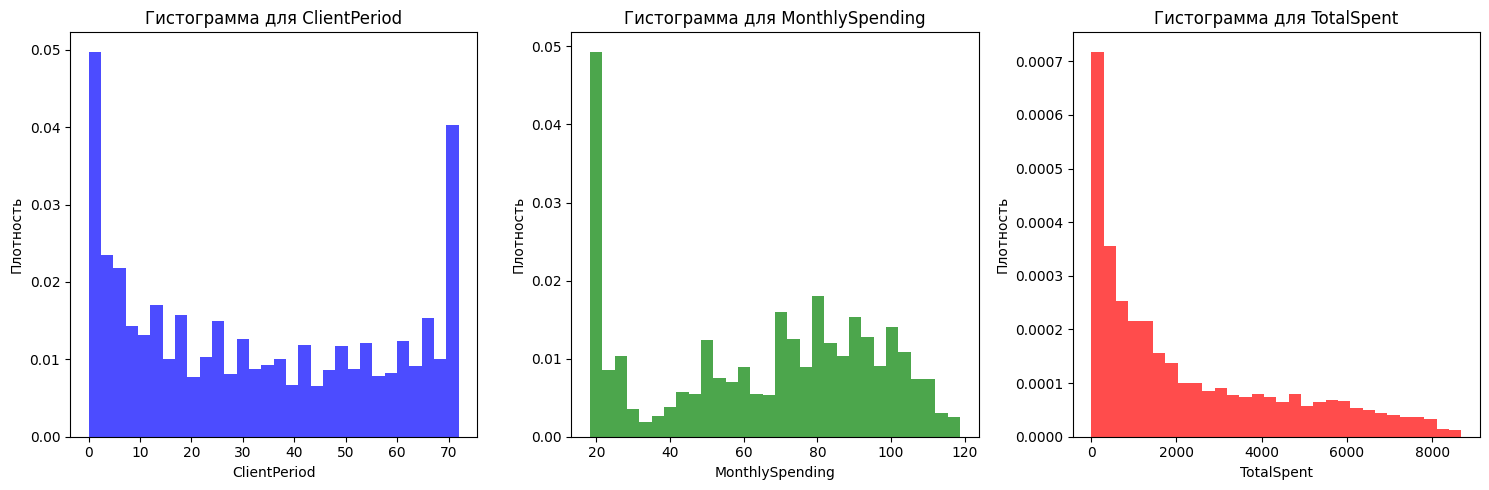

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Гистограмма для ClientPeriod
axes[0].hist(data['ClientPeriod'], bins=30, density=True, color='blue', alpha=0.7)
axes[0].set_xlabel('ClientPeriod')
axes[0].set_ylabel('Плотность')
axes[0].set_title('Гистограмма для ClientPeriod')

# Гистограмма для MonthlySpending
axes[1].hist(data['MonthlySpending'], bins=30, density=True, color='green', alpha=0.7)
axes[1].set_xlabel('MonthlySpending')
axes[1].set_ylabel('Плотность')
axes[1].set_title('Гистограмма для MonthlySpending')

# Гистограмма для TotalSpent
axes[2].hist(data['TotalSpent'], bins=30, density=True, color='red', alpha=0.7)
axes[2].set_xlabel('TotalSpent')
axes[2].set_ylabel('Плотность')
axes[2].set_title('Гистограмма для TotalSpent')

plt.tight_layout()
plt.show()


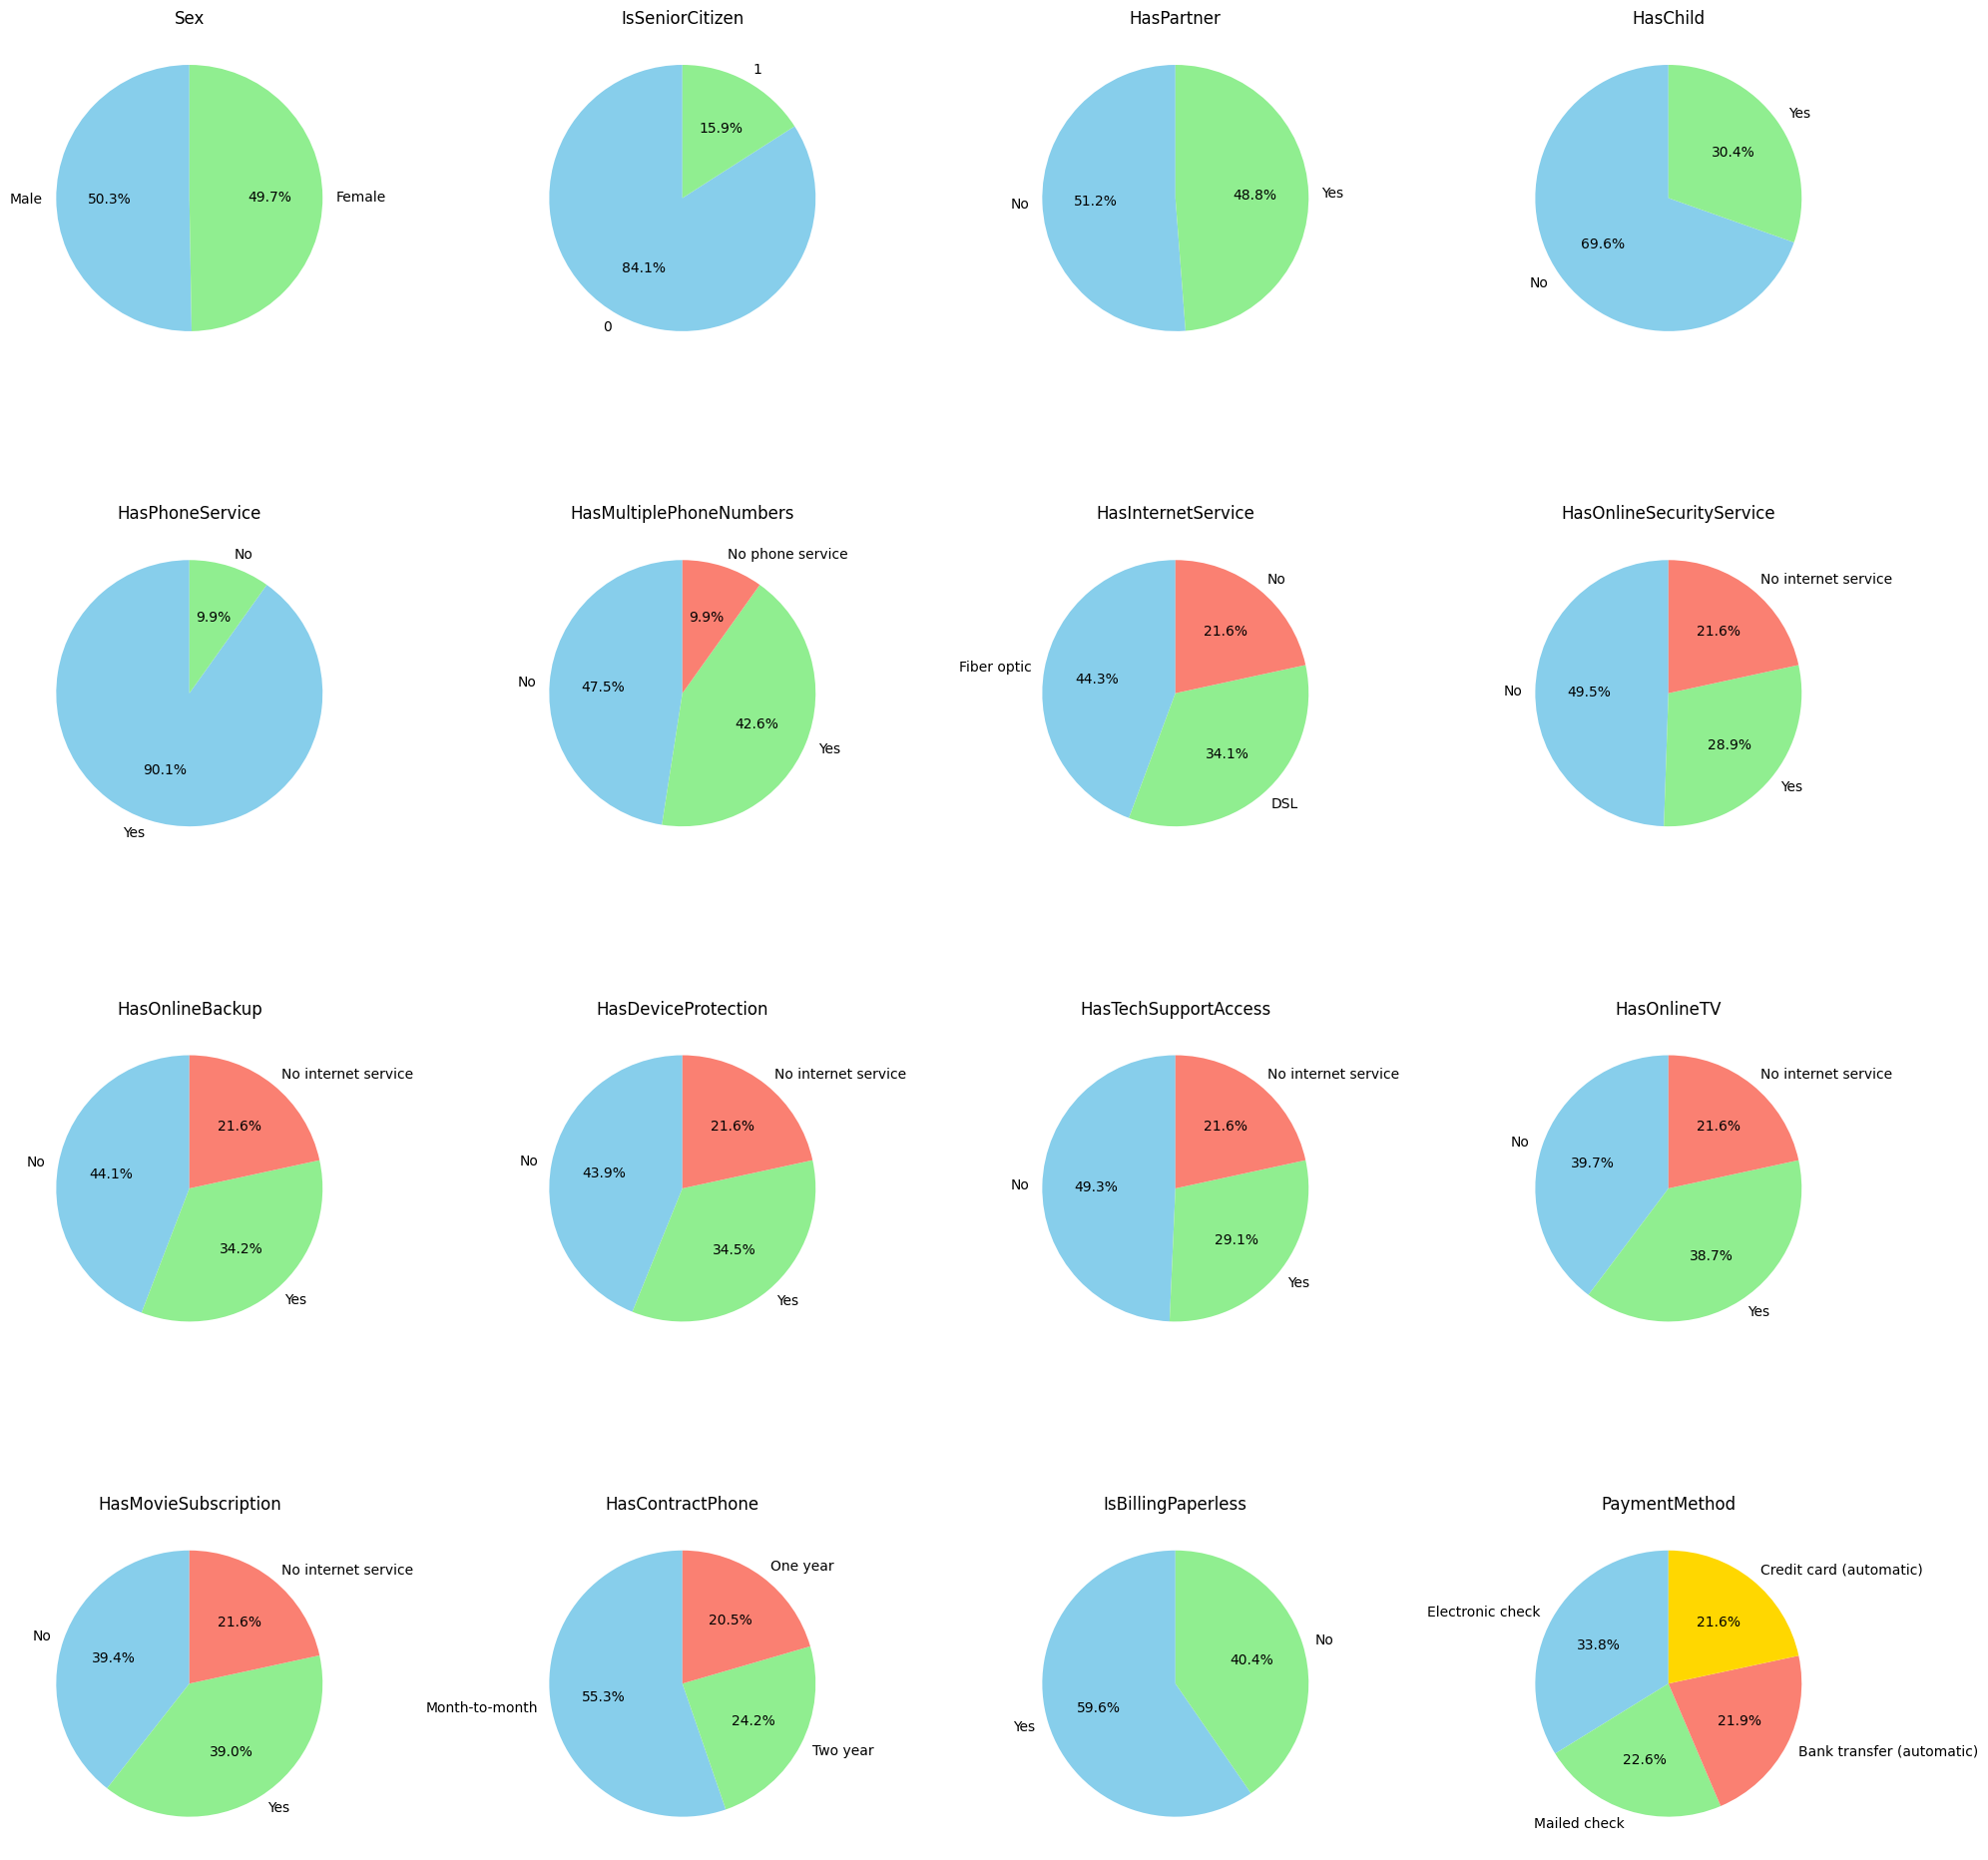

In [ ]:
# Построение круговых диаграмм для каждого категориального признака
fig, axes = plt.subplots(4, 4, figsize=(20, 20))

axes = axes.ravel()  # Преобразуем двумерный массив в одномерный для удобства


for i, col in enumerate(cat_cols):
    value_counts = data[col].value_counts()
    axes[i].pie(value_counts, labels=value_counts.index, autopct='%1.1f%%', startangle=90, colors=['skyblue', 'lightgreen', 'salmon', 'gold'])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

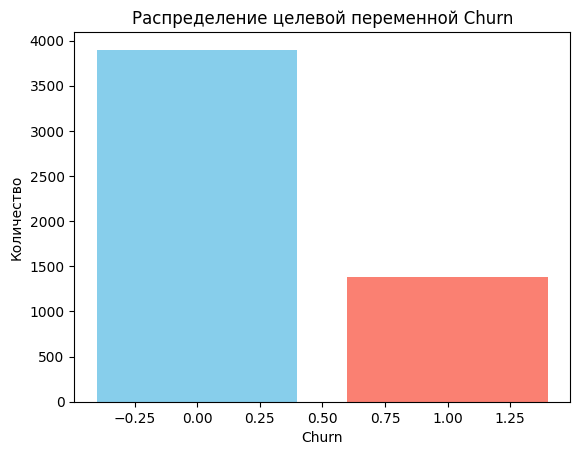

In [ ]:
# Подсчет количества значений каждого класса
target_counts = data[target_col].value_counts()

plt.bar(target_counts.index, target_counts.values, color=['skyblue', 'salmon'])
plt.xlabel('Churn')
plt.ylabel('Количество')
plt.title('Распределение целевой переменной Churn')
plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, RobustScaler, LabelEncoder, OneHotEncoder
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [ ]:
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ])

# Применим преобразования к данным
X = data.drop('Churn', axis=1)
y = data['Churn']

X_processed = preprocessor.fit_transform(X)


Выпишите какое лучшее качество и с какими параметрами вам удалось получить

In [ ]:
# Создадим pipeline
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

# Определим параметры для GridSearchCV
param_grid = {
    'classifier__C': [100, 10, 1, 0.1, 0.01, 0.001]
}

# Создадим GridSearchCV
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='roc_auc', refit=True)

# Обучим модель
grid_search.fit(X, y)

# Выведем лучший параметр C и значение метрики ROC-AUC
best_c = grid_search.best_params_['classifier__C']
best_score = grid_search.best_score_

best_score, best_c

# Обучение модели
grid_search.fit(X, y)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('scaler',
                                                                                          StandardScaler())]),
                                                                         ['ClientPeriod',
                                                                          'MonthlySpending',
                                                                          'TotalSpent']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['Sex',
                                                                          'IsSeniorCitizen',
                                                                          'HasPartner',
                                                                          'HasChild',
                                                                          'HasPhoneService',
                                                                          'HasMultiplePh...,
                                                                          'HasInternetService',
                                                                          'HasOnlineSecurityService',
                                                                          'HasOnlineBackup',
                                                                          'HasDeviceProtection',
                                                                          'HasTechSupportAccess',
                                                                          'HasOnlineTV',
                                                                          'HasMovieSubscription',
                                                                          'HasContractPhone',
                                                                          'IsBillingPaperless',
                                                                          'PaymentMethod'])])),
                                       ('classifier',
                                        LogisticRegression(max_iter=1000,
                                                           random_state=42))]),
             param_grid={'classifier__C': [100, 10, 1, 0.1, 0.01, 0.001]},
             scoring='roc_auc')

In [ ]:
# Разделим данные на обучающую и валидационную выборки
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)

# Создадим модель CatBoostClassifier с параметрами по умолчанию
catboost_model = CatBoostClassifier(verbose=0, random_seed=42)

# Обучим модель
catboost_model.fit(
    X_train, y_train,
    cat_features=cat_cols,
    eval_set=(X_valid, y_valid),
    early_stopping_rounds=50
)

# Предскажем вероятности для валидационной выборки
y_valid_pred_proba = catboost_model.predict_proba(X_valid)[:, 1]

# Вычислим метрику ROC-AUC
roc_auc_default = roc_auc_score(y_valid, y_valid_pred_proba)

roc_auc_default

0.8462338817252113

In [ ]:
# Определим параметры для тестирования
params_to_test = {
    'iterations': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.3]
}

best_roc_auc = 0
best_params = {}

# Переберем все комбинации параметров
for iterations in params_to_test['iterations']:
    for learning_rate in params_to_test['learning_rate']:
        # Создадим модель с текущими параметрами
        catboost_model = CatBoostClassifier(
            iterations=iterations,
            learning_rate=learning_rate,
            verbose=0,
            random_seed=42
        )

        # Обучим модель
        catboost_model.fit(
            X_train, y_train,
            cat_features=cat_cols,
            eval_set=(X_valid, y_valid),
            early_stopping_rounds=50
        )

        # Предскажем вероятности для валидационной выборки
        y_valid_pred_proba = catboost_model.predict_proba(X_valid)[:, 1]

        # Вычислим метрику ROC-AUC
        roc_auc = roc_auc_score(y_valid, y_valid_pred_proba)

        # Проверим, улучшилась ли метрика
        if roc_auc > best_roc_auc:
            best_roc_auc = roc_auc
            best_params = {'iterations': iterations, 'learning_rate': learning_rate}

best_roc_auc, best_params


(0.8463924707277309, {'iterations': 100, 'learning_rate': 0.3})

In [ ]:
best_model = grid_search

In [ ]:
# Загрузка файла submission
submission = pd.read_csv('./submission.csv')

# Предсказание вероятностей для тестовых данных
submission['Churn'] = best_model.predict_proba(X_test)[:, 1]

# Сохранение результатов в файл
submission.to_csv('./submission.csv', index=False)